# Final Assessment & Independent Exercise: Multi-Sensor Alternative Spectral Index & Time-Series Export

## Instrucciones

### Create a new Jupyter Notebook in your GitHub repository and replicate what you consider is necessary to reach what is required as follows:

1. Choose one index distinct from NDVI (e.g., EVI, SAVI, or NDWI) for canopy, soil, or moisture evaluation.
2. Generate annual median composites for both Sentinel-2 and Landsat 8 over your area, applying sensor-specific cloud masking (SCL / QA_PIXEL) and Landsat 8 Surface Reflectance scaling factors.
3. Construct Multi-Temporal Stacks: Combine the 10 annual index layers (2016 to 2025) into a single 10-band ee.Image stack for Sentinel-2 and a corresponding 10-band stack for Landsat 8 (renaming bands sequentially as Index_2016, Index_2017, ..., Index_2025).
4. GeoTIFF Export: Export both 10-band image stacks to Google Drive as projected GeoTIFF rasters using the official local CRS for Colombia (EPSG:9377).
5. Commit and push your final .ipynb file to your public GitHub repository.
6. Ensure your notebook contains executed output cells, structured Markdown headers, and code comments explaining your custom study area selection.
7. Copy the direct link to your Jupyter Notebook on GitHub and submit it using the following link

## Importar librerias 

In [1]:
import ee
import geopandas as gpd
from pathlib import Path
import geemap

## Autenticación GEE

In [2]:
ee.Authenticate()

True

### Instalación de la API GEE

In [3]:

try:
    ee.Initialize()
    print("Google Earth Engine initialised successfully.")
except Exception as e:
    print(f"Error initialising GEE: {e}")

C:\Users\Leo\miniconda3\envs\Geoprocesamiento\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(


Google Earth Engine initialised successfully.


## Selección de área de estudio

In [4]:
#tenemos que indicar la ruta en donde está guardado el proyecto y las capas para el procesamiento
root_folder=Path(r"C:\Users\Leo\Documents\GEOPROCESAMIENTO")
# Carcar los municipios de Colombia
gdf = gpd.read_file(root_folder /"municipios_colombia.gpkg")

# verificar el sistema de coordenadas
print(f"Initial CRS: {gdf.crs}")

# Reproyectar al sistema planas EPSG:9377 (sistemanacional)
gdf_unico = gdf.to_crs(epsg=9377)
#revisar los datos, los primero 5
gdf_unico.head()

Initial CRS: EPSG:3116


,DPTO_CCDGO,MPIO_CCDGO,MPIO_CNMBR,MPIO_CDPMP,VERSION,AREA,LATITUD,LONGITUD,STCTNENCUE,STP3_1_SI,...,STP51_PRIM,STP51_SECU,STP51_SUPE,STP51_POST,STP51_13_E,STP51_99_E,Shape_Leng,Shape_Area,Codigo_Mun,geometry
0,18,001,FLORENCIA,18001,2018,2.547638e+09,1.749139,-75.558239,71877.0,32.0,...,48848.0,59610.0,21898.0,4592.0,5892.0,3799.0,2.942508,0.206928,18001,"MULTIPOLYGON (((4730856.146 1800689.038, 47308..."
1,18,029,ALBANIA,18029,2018,4.141221e+08,1.227865,-75.882327,2825.0,24.0,...,1940.0,1712.0,231.0,41.0,215.0,46.0,1.112829,0.033618,18029,"MULTIPOLYGON (((4677933.827 1709133.846, 46779..."
2,18,094,BELÉN DE LOS ANDAQUÍES,18094,2018,1.191619e+09,1.500923,-75.875645,4243.0,54.0,...,3541.0,3340.0,490.0,119.0,720.0,123.0,2.234657,0.096745,18094,"MULTIPOLYGON (((4690015.614 1751610.86, 469000..."
3,18,247,EL DONCELLO,18247,2018,1.106076e+09,1.791386,-75.193944,8809.0,0.0,...,7571.0,6287.0,1029.0,228.0,1095.0,171.0,3.154370,0.089867,18247,"MULTIPOLYGON (((4737450.122 1814755.048, 47374..."
4,18,256,EL PAUJÍL,18256,2018,1.234734e+09,1.617746,-75.234043,5795.0,0.0,...,6072.0,4066.0,639.0,108.0,916.0,99.0,3.529316,0.100309,18256,"MULTIPOLYGON (((4736905.653 1802381.382, 47376..."


In [5]:
# Calcular área en km² (ya reproyectado a EPSG:9377, en metros)
gdf_unico["area_km2"] = gdf_unico.geometry.area / 1_000_000

# Encontrar el municipio con menor área con la función idxmin()
municipio_mas_pequeno = gdf_unico.loc[gdf_unico["area_km2"].idxmin()]

#mostar el municipio seleccionado 
print(f"Municipio con menor área: {municipio_mas_pequeno['MPIO_CNMBR']}")
print(f"Área: {municipio_mas_pequeno['area_km2']:.2f} km²")

Municipio con menor área: SABANETA
Área: 15.83 km²


## Filtrar por municipio y seleccionar SABANETA

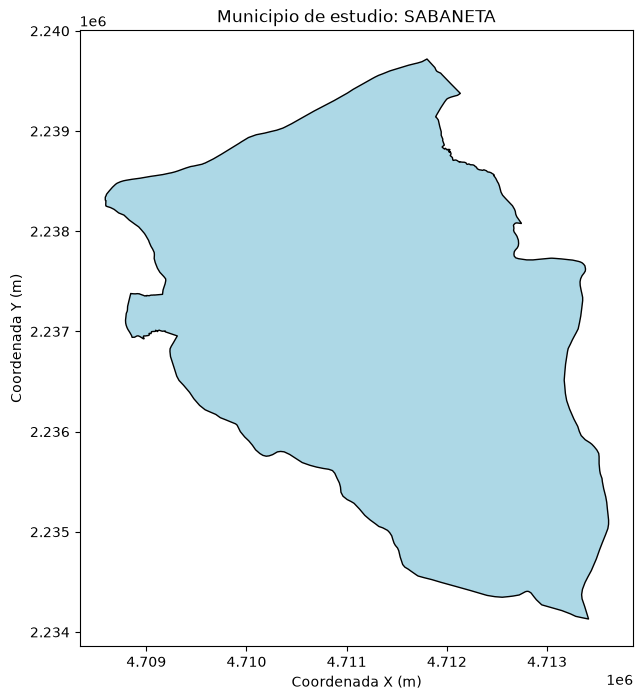

In [6]:
#para mapear el municipio de Sabaneta tenemos que importar la laibreria para hacerplots 
import matplotlib.pyplot as plt

# Filtrar el municipio seleccionado (Sabaneta)
gdf_muni = gdf_unico[gdf_unico["MPIO_CNMBR"] == "SABANETA"].copy()

# Graficar. aca se le puede colocar un titulo al mapa y un cor del poligono 
fig, ax = plt.subplots(figsize=(8, 8))
gdf_muni.plot(ax=ax, color="lightblue", edgecolor="black")
ax.set_title(f"Municipio de estudio: {gdf_muni['MPIO_CNMBR'].iloc[0]}")
ax.set_xlabel("Coordenada X (m)")
ax.set_ylabel("Coordenada Y (m)")
plt.show()

## Convertir la geometría del municipioa formato Earth Engine

In [7]:
#tenemos que reproyectal al sistema de coordenadas que usa GEE epsg=4326
bbox = gdf_muni.to_crs(epsg=4326).total_bounds
ee_bounds = ee.Geometry.BBox(bbox[0], bbox[1], bbox[2], bbox[3])

geojson_geom = gdf_muni.to_crs(epsg=4326).geometry.iloc[0].__geo_interface__
ee_muni_geom = ee.Geometry(geojson_geom)

# Definir las funciones de máscara de nubes (S2 y L8)

In [8]:
# Seleccionar la banda de clasificación de escena y luego Identificar nubes
def mask_s2_clouds_scl(image):
    """Masks clouds, cloud shadows, and cirrus using the SCL band."""
    scl = image.select('SCL') 
    cloud_shadows = scl.eq(3)
    clouds_medium = scl.eq(8)
    clouds_high = scl.eq(9)
    cirrus = scl.eq(10)
    mask = cloud_shadows.Or(clouds_medium).Or(clouds_high).Or(cirrus).Not() # Excluir los píxeles con nubes
    return image.updateMask(mask)

def mask_l8_clouds_qa(image):
    """Masks clouds and cloud shadows using QA_PIXEL band for Landsat 8 C2 L2."""
    qa = image.select('QA_PIXEL')
    cloud_shadow = 1 << 4
    cloud = 1 << 3
    mask = qa.bitwiseAnd(cloud_shadow).eq(0).And(qa.bitwiseAnd(cloud).eq(0))
    return image.updateMask(mask) # Mantener únicamente píxeles sin nubes ni sombra

## Diagnóstico: verificar disponibilidad de imágenes por año
### para que no hayan errores posteriores necesitamos garantizar que cada año tenga almenos una imagen que funcione

In [9]:
# Revisar la disponibilidad anual de imágenes Sentinel-2 y Landsat 8 con 30% de nubosidad 
for y in range(2016, 2026):
    count_s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(ee_muni_geom)
        .filterDate(f"{y}-01-01", f"{y}-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
        .size().getInfo()
    )
    count_l8 = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(ee_muni_geom)
        .filterDate(f"{y}-01-01", f"{y}-12-31")
        .filter(ee.Filter.lt("CLOUD_COVER", 30))
        .size().getInfo()
    )
        # Mostrar el número de imágenes disponibles para cada sensor y año
    print(y, "S2:", count_s2, "| L8:", count_l8)

C:\Users\Leo\miniconda3\envs\Geoprocesamiento\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(


2016 S2: 0 | L8: 1
2017 S2: 2 | L8: 3
2018 S2: 2 | L8: 0
2019 S2: 30 | L8: 3
2020 S2: 28 | L8: 2
2021 S2: 23 | L8: 1
2022 S2: 7 | L8: 1
2023 S2: 26 | L8: 2
2024 S2: 25 | L8: 2
2025 S2: 15 | L8: 0


### Esto demuestra dos problemas 
1. Sentinel-2: solo falla 2016 (0 imágenes). Los demás años tienen suficientes.
2. Landsat 8: faltan imagenes con este criterioen el 2018 y 2025.

In [10]:
# adaptación 

S2_CLOUD_THRESHOLD = 30
L8_CLOUD_THRESHOLD = 40  # 40%, ajustado por baja disponibilidad de L8 en el área de estudio

for y in range(2017, 2026):# del 2017-2025, para que aparezca el 2025 toca estipular como limite el 2026
    count_s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(ee_muni_geom)
        .filterDate(f"{y}-01-01", f"{y}-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", S2_CLOUD_THRESHOLD))
        .size().getInfo()
    )
    count_l8 = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(ee_muni_geom)
        .filterDate(f"{y}-01-01", f"{y}-12-31")
        .filter(ee.Filter.lt("CLOUD_COVER", L8_CLOUD_THRESHOLD)) #40%
        .size().getInfo()
    )
        # Mostrar el número de imágenes disponibles para cada sensor y año
    print(y, "S2:", count_s2, "| L8:", count_l8)

2017 S2: 2 | L8: 3
2018 S2: 2 | L8: 3
2019 S2: 30 | L8: 4
2020 S2: 28 | L8: 4
2021 S2: 23 | L8: 2
2022 S2: 7 | L8: 3
2023 S2: 26 | L8: 2
2024 S2: 25 | L8: 2
2025 S2: 15 | L8: 2


# Escoger indice multiespectral 
### El NDWI (Normalized Difference Water Index) es un índice espectral utilizado para identificar y delimitar cuerpos y superficies de agua, aprovechando la diferencia en la respuesta de la vegetación, el suelo y el agua en determinadas bandas del espectro electromagnético.

### aca se presenta la funcion primero para Sentinel 2 y luego para Landsat 8 

In [11]:
def compute_annual_index_s2(year, geom):
    #definir periodos de análisis
    date_start = ee.Date.fromYMD(year, 1, 1)
    date_end = ee.Date.fromYMD(year, 12, 31)
    #construir colecciones de imagenes
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geom)
        .filterDate(date_start, date_end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", S2_CLOUD_THRESHOLD))
        .map(mask_s2_clouds_scl) #se ocultan pixeles que no cumplen con los criterios de % de nubosidad
        .median() #Crear una imagen representativa del año mediante la mediana
    )
    #Calcular NDWI
    index_img = s2.normalizedDifference(["B3", "B8"]).rename(f"NDWI_{year}")
    #Recortar al área de estudio
    return index_img.clip(geom)

# se hace lo mismo pero para landsat 8
def compute_annual_index_l8(year, geom):
    date_start = ee.Date.fromYMD(year, 1, 1)
    date_end = ee.Date.fromYMD(year, 12, 31)
    def scale_l8(img):
        #Función de escalamiento para usar valores de reflectancia
        optical = img.select('SR_B.').multiply(0.0000275).add(-0.2)
        return img.addBands(optical, None, True)
    l8 = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(geom)
        .filterDate(date_start, date_end)
        .filter(ee.Filter.lt("CLOUD_COVER", L8_CLOUD_THRESHOLD))
        .map(mask_l8_clouds_qa)
        .map(scale_l8)
        .median()
    )
    index_img = l8.normalizedDifference(["SR_B3", "SR_B5"]).rename(f"NDWI_{year}")
    return index_img.clip(geom)

## Visualización ejemplo 

In [12]:
ndwi_2025 = compute_annual_index_s2(2025, ee_muni_geom) #primero tenemos que seleccionar la escena ejemplo 
#necesitamos importar librerias para el plot
import requests
from io import BytesIO
from PIL import Image
import geemap # esta en particular permite tener el mapa base de OSM

#Parámetros de visualización los colores de valores minimos y maximos
vis_params = {
    'min': -0.5,
    'max': 0.5,
    'palette': ['brown', 'white', 'blue']
}

#parametros de ubicacipon del plot: obtener el centro del municipio
centroid_point = gdf_muni.geometry.centroid.to_crs(epsg=4326).iloc[0]
centroid = [centroid_point.y, centroid_point.x]
#Crear el mapa interactivo
Map_ndwi_2025 = geemap.Map(center=centroid, zoom=13)

# Agregar mapa base OpenStreetMap explícitamente
Map_ndwi_2025.add_basemap('OpenStreetMap')

# Agregar la capa de NDWI encima
Map_ndwi_2025.addLayer(ndwi_2025, vis_params, 'NDWI 2025')

Map_ndwi_2025.add_layer_control()
Map_ndwi_2025

Map(center=[6.138305172710664, -75.60880597107997], controls=(WidgetControl(options=['position', 'transparent_…

# Genera la lista de imágenes anuales para cada sensor

In [13]:
# Configuración (ya la tienes correcta)
S2_YEARS = list(range(2017, 2026))
S2_CLOUD_THRESHOLD = 30

L8_YEARS = list(range(2017, 2026))
L8_CLOUD_THRESHOLD = 40

# Regenerar las listas de imágenes
s2_images = [compute_annual_index_s2(y, ee_muni_geom) for y in S2_YEARS]
l8_images = [compute_annual_index_l8(y, ee_muni_geom) for y in L8_YEARS]


## Construir Stacks de imagenes

In [14]:
# Stack de Sentinel-2 (una banda por año, ya renombradas dentro de la función)
s2_stack = ee.Image.cat(s2_images)
print("Bandas S2 stack:", s2_stack.bandNames().getInfo())

# Stack de Landsat 8
l8_stack = ee.Image.cat(l8_images)
print("Bandas L8 stack:", l8_stack.bandNames().getInfo())

Bandas S2 stack: ['NDWI_2017', 'NDWI_2018', 'NDWI_2019', 'NDWI_2020', 'NDWI_2021', 'NDWI_2022', 'NDWI_2023', 'NDWI_2024', 'NDWI_2025']
Bandas L8 stack: ['NDWI_2017', 'NDWI_2018', 'NDWI_2019', 'NDWI_2020', 'NDWI_2021', 'NDWI_2022', 'NDWI_2023', 'NDWI_2024', 'NDWI_2025']


## Verificación del stecks 

In [15]:
print("N° bandas S2:", len(s2_stack.bandNames().getInfo()))
print("N° bandas L8:", len(l8_stack.bandNames().getInfo()))

N° bandas S2: 9
N° bandas L8: 9


## Definición de variable con la proyección

In [16]:
crs_utm = 'EPSG:32618'  # UTM 18N — sistema estándar reconocido por GEE
print(repr(crs_utm))

'EPSG:32618'


# Exportar

In [19]:
# Definir la proyección MAGNA-SIRGAS / Origen-Nacional (EPSG:9377) como cadena PROJ4,
# ya que Earth Engine no reconoce directamente el código EPSG:9377
crs_9377 = "+proj=tmerc +lat_0=4 +lon_0=-73 +k=0.9992 +x_0=5000000 +y_0=2000000 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs"
#Exportar sentinel 2
task_s2 = ee.batch.Export.image.toDrive(
    image=s2_stack,
    description='NDWI_Sentinel2_2017_2025_Sabaneta',
    folder='Resultados1',
    fileNamePrefix='NDWI_S2_Sabaneta_2017_2025_UTM18N',
    region=ee_muni_geom,
    scale=10,
    crs=crs_utm,
    maxPixels=1e9
)
task_s2.start()
print("Exportación de Sentinel-2 iniciada (UTM 18N).")

#Exportar landsat 8
task_l8 = ee.batch.Export.image.toDrive(
    image=l8_stack,
    description='NDWI_Landsat8_2017_2025_Sabaneta',
    folder='Resultados1',
    fileNamePrefix='NDWI_L8_Sabaneta_2017_2025_UTM18N',
    region=ee_muni_geom,
    scale=30,
    crs=crs_utm,
    maxPixels=1e9
)
task_l8.start()
print("Exportación de Landsat 8 iniciada (UTM 18N).")

Exportación de Sentinel-2 iniciada (UTM 18N).
Exportación de Landsat 8 iniciada (UTM 18N).


## Verificación 

In [20]:
print(task_s2.status())
print(task_l8.status())

{'state': 'READY', 'description': 'NDWI_Sentinel2_2017_2025_Sabaneta', 'priority': 100, 'creation_timestamp_ms': 1789304282407, 'update_timestamp_ms': 1789304287590, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'FPZTNUAT7B7A2KM2HU3HO3BN', 'name': 'projects/312893530331/operations/FPZTNUAT7B7A2KM2HU3HO3BN'}
{'state': 'READY', 'description': 'NDWI_Landsat8_2017_2025_Sabaneta', 'priority': 100, 'creation_timestamp_ms': 1789304283250, 'update_timestamp_ms': 1789304283250, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'LDY2WNM2S456DXU242GDDZEZ', 'name': 'projects/312893530331/operations/LDY2WNM2S456DXU242GDDZEZ'}


# Ver resultados 

https://drive.google.com/drive/folders/1maKF4Zu0e8GJZzUFrwYgOTPze3UcM6IB?usp=sharing